# Task 1 & 2 – Data Exploration

This notebook explores the two benchmark datasets used in the thesis:
- **WDC Products** (small, 80% corner cases)
- **DBLP-Scholar** (citation matching, different domain)

We inspect class balance, pair statistics, and sample entity serializations.

In [7]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
PROCESSED = ROOT / 'data' / 'processed'

FIGURES = ROOT / "thesis-docs" / "thesis-paper" / "figures"

In [8]:
ROOT

PosixPath('/Users/abd/Developer/thesis-project')

## Helper – load Ditto-format text files

In [9]:
def load_split(dataset: str, split: str) -> pd.DataFrame:
    path = PROCESSED / dataset / f'{split}.txt'
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip('\n').split('\t')
            if len(parts) == 3:
                rows.append({'left': parts[0], 'right': parts[1], 'label': int(parts[2])})
    return pd.DataFrame(rows)

## 1. WDC Products

In [10]:
wdc_train = load_split('wdc-products', 'train')
wdc_valid = load_split('wdc-products', 'valid')
wdc_test  = load_split('wdc-products', 'test')

print('=== WDC Products ===')
for name, df in [('train', wdc_train), ('valid', wdc_valid), ('test', wdc_test)]:
    n = len(df)
    pos = df['label'].sum()
    print(f'  {name:5s}: {n:5,} pairs | {pos:4,} matches ({100*pos/n:.1f}%) | {n-pos:5,} non-matches')

=== WDC Products ===
  train: 2,500 pairs |  500 matches (20.0%) | 2,000 non-matches
  valid: 2,500 pairs |  500 matches (20.0%) | 2,000 non-matches
  test : 4,500 pairs |  500 matches (11.1%) | 4,000 non-matches


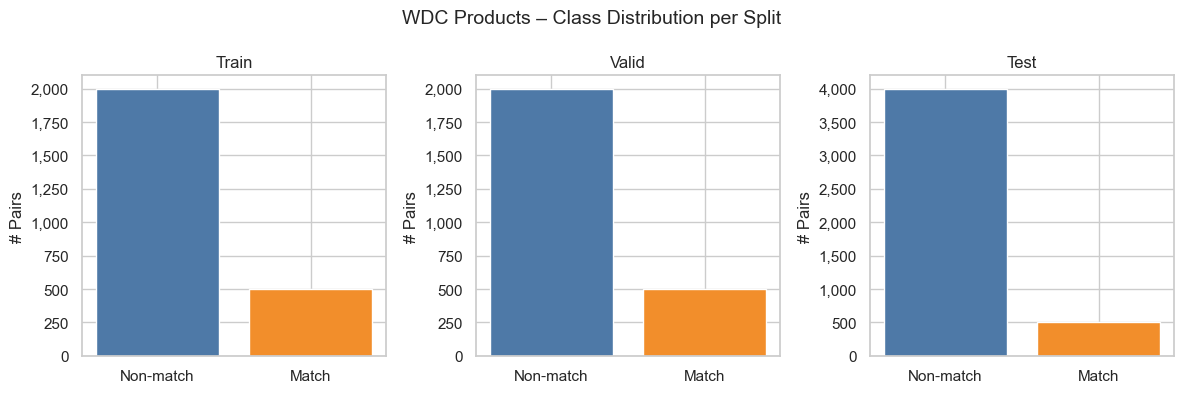

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
fig.suptitle('WDC Products – Class Distribution per Split', fontsize=14)

for ax, (name, df) in zip(axes, [('Train', wdc_train), ('Valid', wdc_valid), ('Test', wdc_test)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Non-match', 'Match'], [counts.get(0, 0), counts.get(1, 0)], color=['#4e79a7', '#f28e2b'])
    ax.set_title(name)
    ax.set_ylabel('# Pairs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(FIGURES / "wdc_class_distribution.pdf", bbox_inches='tight')
plt.show()

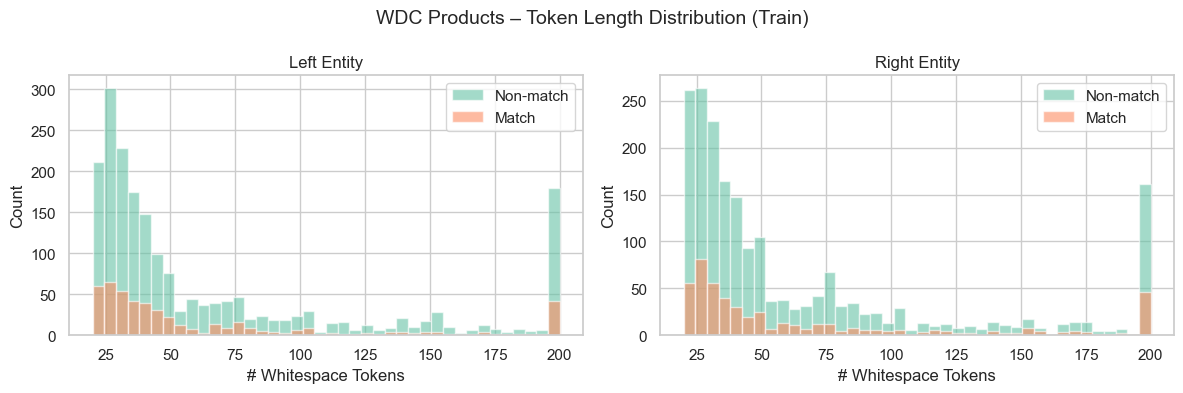

In [12]:
# Token length distribution for left entity serializations
wdc_train['left_tokens'] = wdc_train['left'].str.split().str.len()
wdc_train['right_tokens'] = wdc_train['right'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('WDC Products – Token Length Distribution (Train)', fontsize=14)

for ax, col, title in zip(axes, ['left_tokens', 'right_tokens'], ['Left Entity', 'Right Entity']):
    for label, grp in wdc_train.groupby('label'):
        name = 'Match' if label == 1 else 'Non-match'
        ax.hist(grp[col].clip(upper=200), bins=40, alpha=0.6, label=name)
    ax.set_title(title)
    ax.set_xlabel('# Whitespace Tokens')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES / "wdc_token_length_distribution.pdf", bbox_inches='tight')
plt.show()

In [13]:
print('=== WDC Products Sample Pairs ===')
for _, row in wdc_train.sample(3, random_state=42).iterrows():
    print(f"Label : {row['label']} ({'MATCH' if row['label'] else 'NON-MATCH'})")
    print(f"Left  : {row['left'][:200]}")
    print(f"Right : {row['right'][:200]}")
    print()

=== WDC Products Sample Pairs ===
Label : 0 (NON-MATCH)
Left  : COL brand VAL  COL title VAL DYMO 4500 TAPE BLACK/RED 45017 COL description VAL Dymo 4500 Tape 12mmx7m Black/Red 45017. COL price VAL 11.49 COL priceCurrency VAL GBP
Right : COL brand VAL  COL title VAL SDS2/32GB, 32GB SDHC Canvas Select Plus 100R C10 UHS-I U1 V10 COL description VAL  COL price VAL  COL priceCurrency VAL 

Label : 0 (NON-MATCH)
Left  : COL brand VAL SanDisk COL title VAL SanDisk Extreme Pro SD Card 32GB 300MB/s UHS-II COL description VAL  COL price VAL 56.45 COL priceCurrency VAL EUR
Right : COL brand VAL  COL title VAL CS-M8000 CASSETTE 11-40 XT 11-SPEED COL description VAL CS-M8000 CASSETTE 11-40 XT 11-SPEED COL price VAL 1.49E2 COL priceCurrency VAL NZD

Label : 0 (NON-MATCH)
Left  : COL brand VAL  COL title VAL Canon Ink Jet Cartridge PGI-72 PBK/GY/PM/PC/CO Multipack 40433 COL description VAL  COL price VAL 55.99 COL priceCurrency VAL 
Right : COL brand VAL Dymo COL title VAL Dymo 40913 Black On White 

## 2. DBLP-Scholar

In [14]:
dblp_train = load_split('dblp-scholar', 'train')
dblp_valid = load_split('dblp-scholar', 'valid')
dblp_test  = load_split('dblp-scholar', 'test')

print('=== DBLP-Scholar ===')
for name, df in [('train', dblp_train), ('valid', dblp_valid), ('test', dblp_test)]:
    n = len(df)
    pos = df['label'].sum()
    print(f'  {name:5s}: {n:6,} pairs | {pos:5,} matches ({100*pos/n:.1f}%) | {n-pos:6,} non-matches')

=== DBLP-Scholar ===
  train: 17,223 pairs | 3,207 matches (18.6%) | 14,016 non-matches
  valid:  5,742 pairs | 1,070 matches (18.6%) |  4,672 non-matches
  test :  5,742 pairs | 1,070 matches (18.6%) |  4,672 non-matches


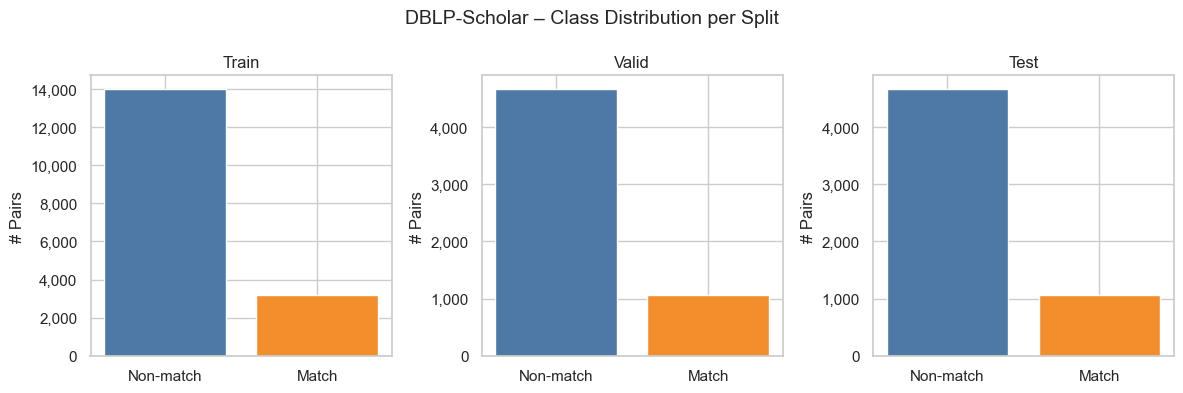

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
fig.suptitle('DBLP-Scholar – Class Distribution per Split', fontsize=14)

for ax, (name, df) in zip(axes, [('Train', dblp_train), ('Valid', dblp_valid), ('Test', dblp_test)]):
    counts = df['label'].value_counts().sort_index()
    ax.bar(['Non-match', 'Match'], [counts.get(0, 0), counts.get(1, 0)], color=['#4e79a7', '#f28e2b'])
    ax.set_title(name)
    ax.set_ylabel('# Pairs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(FIGURES / "dblp_class_distribution.pdf", bbox_inches='tight')
plt.show()

In [16]:
print('=== DBLP-Scholar Sample Pairs ===')
for _, row in dblp_train.sample(3, random_state=42).iterrows():
    print(f"Label : {row['label']} ({'MATCH' if row['label'] else 'NON-MATCH'})")
    print(f"Left  : {row['left'][:250]}")
    print(f"Right : {row['right'][:250]}")
    print()

=== DBLP-Scholar Sample Pairs ===
Label : 0 (NON-MATCH)
Left  : COL title VAL dwms : data warehouse management system COL authors VAL n mohan COL venue VAL vldb COL year VAL 1996
Right : COL title VAL ã cents â ? ¬ å?dynamat : a dynamic view management system for data warehousesã cents â ? ¬ â ? COL authors VAL y kotidis , n roussopoulos COL venue VAL proc . of the acm sigmod COL year VAL 

Label : 0 (NON-MATCH)
Left  : COL title VAL guest editorial COL authors VAL  COL venue VAL  COL year VAL 2003
Right : COL title VAL guest editor 's introduction COL authors VAL f highland COL venue VAL ieee expert : intelligent systems and their applications , COL year VAL 1994.0

Label : 0 (NON-MATCH)
Left  : COL title VAL editorial COL authors VAL  COL venue VAL  COL year VAL 2001
Right : COL title VAL editorial COL authors VAL mt norris , pa martin COL venue VAL bt technology journal , COL year VAL 1999.0



## 3. Dataset Summary

In [17]:
summary = []
for ds_name, splits in [
    ('WDC Products', {'train': wdc_train, 'valid': wdc_valid, 'test': wdc_test}),
    ('DBLP-Scholar', {'train': dblp_train, 'valid': dblp_valid, 'test': dblp_test}),
]:
    for split, df in splits.items():
        n = len(df)
        pos = int(df['label'].sum())
        summary.append({
            'Dataset': ds_name,
            'Split': split,
            'Total Pairs': n,
            'Matches': pos,
            'Non-matches': n - pos,
            'Match Rate': f'{100*pos/n:.1f}%',
        })

pd.DataFrame(summary).set_index(['Dataset', 'Split'])

Total Pairs  Matches  Non-matches Match Rate
Dataset      Split                                              
WDC Products train         2500      500         2000      20.0%
             valid         2500      500         2000      20.0%
             test          4500      500         4000      11.1%
DBLP-Scholar train        17223     3207        14016      18.6%
             valid         5742     1070         4672      18.6%
             test          5742     1070         4672      18.6%